progetto ABIML 2025-26

Bresciani G.

Loreggia C.

Magni G.

Rota Biasetti S.

# Section 1



Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Cell to download the dataset from Hugging Face and save it directly to your Google Drive. (Run only once)

Data Loading
Note: Just like in our lab sessions, we don't use our own images. Instead, we use a dataset from Hugging Face. There are two ways to do this:

Method 1 — Local Caching: Downloading the data directly from Hugging Face to the Colab temporary memory.

Method 2 — Google Drive: Saving the data on Google Drive and connecting it to Colab.

Our Choice: The Alzheimer MRI dataset is only 30MB. Because it is so small, we decided to use Method 2 (Google Drive).

Usually, moving data between Drive and Colab can be slow, but for 30MB the delay is not a problem. Also, both services use Google’s infrastructure, so the speed is very fast. Using "streaming" or "lazy loading" from Hugging Face is only necessary for very large datasets (100GB or more). For this project, saving it to Drive is the easiest and best solution.

In [ ]:
from datasets import load_dataset

#Downloading all dataset from HF
dataset = load_dataset("Falah/Alzheimer_MRI")

# Save on Drive (.arrow)
dataset.save_to_disk("/content/drive/MyDrive/Project_For_ABIAML/dataset")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Saving the dataset (0/1 shards):   0%|          | 0/5120 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/1280 [00:00<?, ? examples/s]

In [ ]:
import os
DATA_FOLDER = os.path.join("/content/drive/MyDrive/Project_For_ABIAML/dataset")
print("Available folders:", os.listdir(DATA_FOLDER))

Available folders: ['train', 'test', 'dataset_dict.json']


In [ ]:
from datasets import load_from_disk

dataset = load_from_disk(DATA_FOLDER)
import numpy as np
import matplotlib.pyplot as plt


# analisi del numero di canali di colore ( nessuno = 1 implicito, 3 = RBG, 4= RGBA)
shapes_train = set(np.array(img['image']).shape for img in dataset['train'])
shapes_test  = set(np.array(img['image']).shape for img in dataset['test'])
print(f"Shape uniche train: {shapes_train}")
print(f"Shape uniche test:  {shapes_test}")




# --- 1. ESPLORAZIONE DEL DATASET ---
print("--- Dimensioni del Dataset ---")
for split in dataset.keys():
    print(f"Split '{split}': {len(dataset[split])} immagini")

# --- 2. ESTRAZIONE DINAMICA DELLE ETICHETTE ---
# Estraiamo i nomi direttamente dalle "features" del dataset di train
label_names = dataset['train'].features['label'].names
print(f"\n--- Associazione Etichette-Numeri ---")
for num, name in enumerate(label_names):
    print(f"Label {num} -> {name}")

# --- 3. CONVERSIONE E NORMALIZZAZIONE ---
print("\n--- Dettagli Immagine e Normalizzazione (Singolo Campione) ---")
# Prendiamo la prima immagine per controllare i valori
sample = dataset['train'][0]
img_array_originale = np.array(sample['image'])

print(f"Shape immagine: {img_array_originale.shape}")
print(f"Valori originali dei pixel - Min: {img_array_originale.min()}, Max: {img_array_originale.max()}")

# Eseguiamo la normalizzazione da 0 a 1
img_array_normalizzata = img_array_originale / 255.0
print(f"Valori normalizzati (0-1) - Min: {img_array_normalizzata.min()}, Max: {img_array_normalizzata.max()}")

# --- 4. VISUALIZZAZIONE DI UN ESEMPIO PER CLASSE ---
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
shown = {}

# Cerchiamo dinamicamente un'immagine per ciascuna delle 4 categorie
for sample in dataset['train']:
    l = sample['label']
    # Se non abbiamo ancora un'immagine per questa label, la salviamo
    if l not in shown:
        # La convertiamo e la normalizziamo prima di salvarla
        img_norm = np.array(sample['image']) / 255.0
        shown[l] = img_norm
    # Se le abbiamo trovate tutte e 4, fermiamo il ciclo
    if len(shown) == 4:
        break

# Disegniamo le 4 immagini trovate, in ordine di etichetta
for i, (l, img) in enumerate(sorted(shown.items())):
    axes[i].imshow(img, cmap='gray') # cmap='gray' gestisce perfettamente i valori normalizzati 0-1
    axes[i].set_title(f"[{l}] {label_names[l]}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()


Shape uniche train: {(128, 128)}
Shape uniche test:  {(128, 128)}


In [ ]:
category_counts = {name: {'train': 0, 'test': 0} for name in label_names}

for split_name in ['train', 'test']:
    for sample in dataset[split_name]:
        label_index = sample['label']
        category_name = label_names[label_index]
        category_counts[category_name][split_name] += 1

print("--- Conteggio immagini per categoria ---")
for category, counts in category_counts.items():
    print(f"Categoria '{category}':")
    print(f"  Training set: {counts['train']} immagini")
    print(f"  Test set: {counts['test']} immagini")
    print(f"  Totale: {counts['train'] + counts['test']} immagini\n")

--- Conteggio immagini per categoria ---
Categoria 'Mild_Demented':
  Training set: 724 immagini
  Test set: 172 immagini
  Totale: 896 immagini

Categoria 'Moderate_Demented':
  Training set: 49 immagini
  Test set: 15 immagini
  Totale: 64 immagini

Categoria 'Non_Demented':
  Training set: 2566 immagini
  Test set: 634 immagini
  Totale: 3200 immagini

Categoria 'Very_Mild_Demented':
  Training set: 1781 immagini
  Test set: 459 immagini
  Totale: 2240 immagini



**Class Distribution**

Before building any model, it is essential to understand how the dataset is distributed across the different classes.

A "balanced" dataset is important. If the dataset is unbalanced (meaning one class has many more images than the others), the network might "cheat." It could learn to always predict the most frequent class to get a high accuracy score, but it would completely fail to recognize the rare classes.

This is a critical issue in the medical field, where the rarest classes are often the most important to identify correctly.

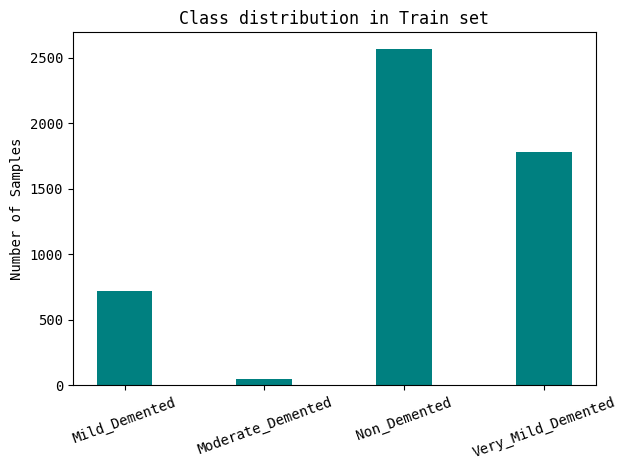

In [ ]:
import numpy as np

label_names = dataset['train'].features['label'].names
# label_names è una lista ["Mild_Demented", "Moderate_Demented",
# "Non_Demented", "Very_Mild_Demented"] — ci serve per stampare i nomi
# invece dei numeri 0,1,2,3

train_labels = np.array(dataset['train']['label'])

unique, counts = np.unique(train_labels, return_counts=True)
# np.unique trova i valori unici in train_labels (0,1,2,3) e conta
# quante volte appare ciascuno → unique=[0,1,2,3], counts=[n0,n1,n2,n3]

plt.rcParams['font.family'] = 'monospace'
plt.rcParams['font.size'] = 10
plt.bar([label_names[i] for i in unique], counts, color=(0, 0.5, 0.5),width=0.4)
plt.title('Class distribution in Train set', loc='center')
plt.ylabel('Number of Samples')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()



Looking at our data: 'Non_Demented' has 2566 training images while 'Moderate_Demented' has only 49. a ratio of about 52:1. One practical solution is to use class weights during training so the model receives a higher penalty when it makes an error on a rare class, forcing it to pay more attention to them.

# Eliminare questa nota prima della consegna

Ricordiamoci di fare una versione applicando il peso dell'errore 'maggiore' per la classe con pochi elementi

# Section 2

In the next cell, we demonstrate how to reduce the number of samples to shorten training time. This approach is often necessary to prevent RAM limitations and crashes. However, in the subsequent steps, we will use the full dataset to maximize the model's accuracy and performance.

In [ ]:
import random
from datasets import Dataset

MAX = 500

def subsample(split):
    indices = {name: [] for name in label_names}
    for i, s in enumerate(dataset[split]):
        indices[label_names[s['label']]].append(i)
    kept = []
    for name, idx in indices.items():
        kept += random.sample(idx, min(MAX, len(idx)))
    return dataset[split].select(kept)

train_balanced = subsample('train')
print({label_names[i]: sum(1 for s in train_balanced if s['label']==i) for i in range(len(label_names))})

{'Mild_Demented': 500, 'Moderate_Demented': 49, 'Non_Demented': 500, 'Very_Mild_Demented': 500}


In [ ]:
# Questa cella estrae, normalizza, shuffla e prepara train e test
# tutto in una volta sola — nessuna operazione viene ripetuta altrove
import numpy as np
from keras.utils import to_categorical

print("--- 1. Estrazione e Conversione in NumPy ---")
# Estraiamo le immagini, le convertiamo in array NumPy
# Ci vorrà qualche secondo per caricare tutto in memoria
train_images = np.array([np.array(img) for img in dataset['train']['image']])
train_labels = np.array(dataset['train']['label'])

print(f"Dimensioni train_images: {train_images.shape}")

print("\n--- 2. Shuffle (Mescolamento) dei dati ---")
'''
 Shuffle training data (esattamente con la logica usata a lezione)
 Shuffle using np.random.permutation: applies the same random index order
 to both images and labels.
 Not stratified (dataset is just splitted)
 Seed fixed for reproducibility.
'''
# primo tentativo a 42 poi cambiato per verificare
seed=42
np.random.seed(seed)
train_idx = np.random.permutation(len(train_images))
train_images = train_images[train_idx]
train_labels = train_labels[train_idx]

print("Dati mescolati con successo!")

print("\n--- 3. Normalizzazione (0-1) e aggiunta canale ---")
# Normalizziamo qui una volta sola per train e test
# expand_dims aggiunge il canale: (N,128,128) -> (N,128,128,1)
train_images = np.expand_dims(train_images / 255.0, axis=-1)
test_images  = np.expand_dims(
    np.array([np.array(img) for img in dataset['test']['image']]) / 255.0,
    axis=-1
)
test_labels     = np.array(dataset['test']['label'])

print(f"Train shape: {train_images.shape}, max pixel: {train_images.max()}")
print(f"Test shape:  {test_images.shape},  max pixel: {test_images.max()}")

print("\n--- 4. One-Hot Encoding delle etichette ---")
# One-hot encode labels: num_classes=4 (perché abbiamo 4 categorie!)
# Es: 0 -> [1, 0, 0, 0] | 1 -> [0, 1, 0, 0] | ecc...
train_labels_cat = to_categorical(train_labels, num_classes=4)
test_labels_cat  = to_categorical(test_labels,  num_classes=4)

print(f"Esempio codifica etichetta: {int(train_labels[0])} -> {train_labels_cat[0]}")

--- 1. Estrazione e Conversione in NumPy ---
Dimensioni train_images: (5120, 128, 128)

--- 2. Shuffle (Mescolamento) dei dati ---
Dati mescolati con successo!

--- 3. Normalizzazione (0-1) e aggiunta canale ---
Train shape: (5120, 128, 128, 1), max pixel: 1.0
Test shape:  (1280, 128, 128, 1),  max pixel: 1.0

--- 4. One-Hot Encoding delle etichette ---
Esempio codifica etichetta: 0 -> [1. 0. 0. 0.]


Nel prossimo passaggio, scegliamo un modello preaddestrato, e iniziamo a fargli leggere le immagini

Utilizziamo un modello "non pre addestrato" per iniziare. Questo perche è più semplice aggiungere pezzi al modello man mano che procediamo, piuttosto che dover 'ripulire' o modificare un modello complesso già esistente per adattarlo alle nostre immagini.

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

model = models.Sequential([
    # Estrazione features
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 1)), # solo scala di grigi, se fosse rgb sarebbe (128, 128, 3)
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Appiattimento e Classificazione finale
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(4, activation='softmax') # 4 neuroni in output per le 4 classi
])

# Compilazione del modello
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Stampa la tabella riassuntiva
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,580 (12.61 MB)

 Trainable params: 3,304,580 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

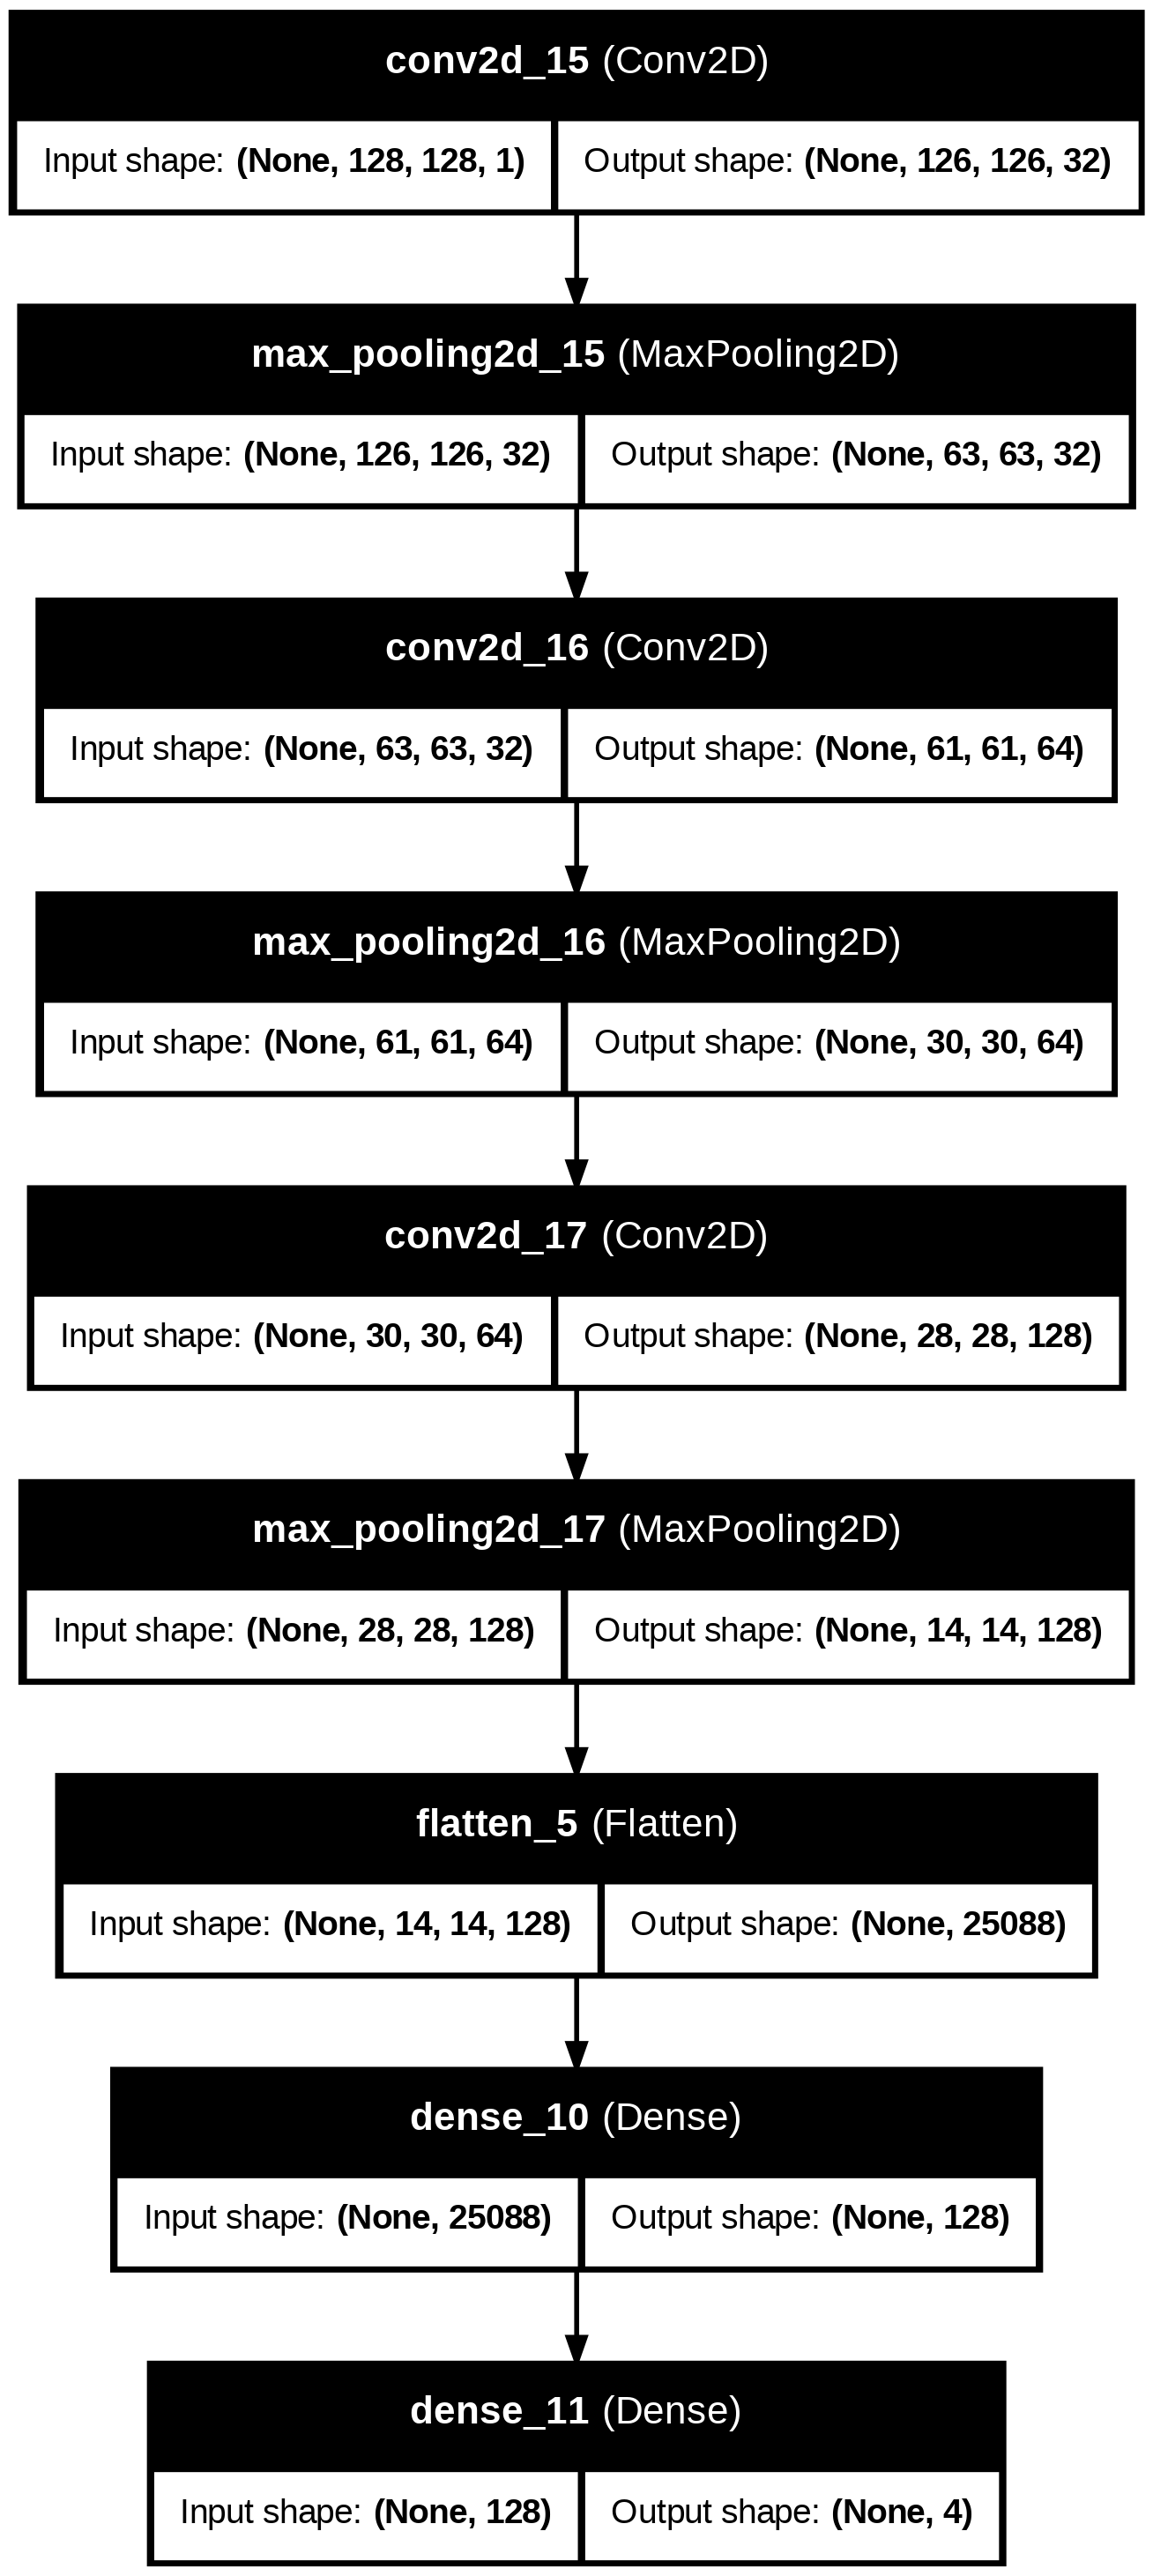

In [ ]:
# Visualizzazione grafica dell'architettura
tf.keras.utils.plot_model(
    model,
    to_file='model_architecture.png', # Salva anche l'immagine nel tuo Drive/Colab
    show_shapes=True,                  # Mostra le dimensioni degli input/output (fondamentale!)
    show_layer_names=True              # Mostra il nome di ogni livello (es. conv2d_1)
)

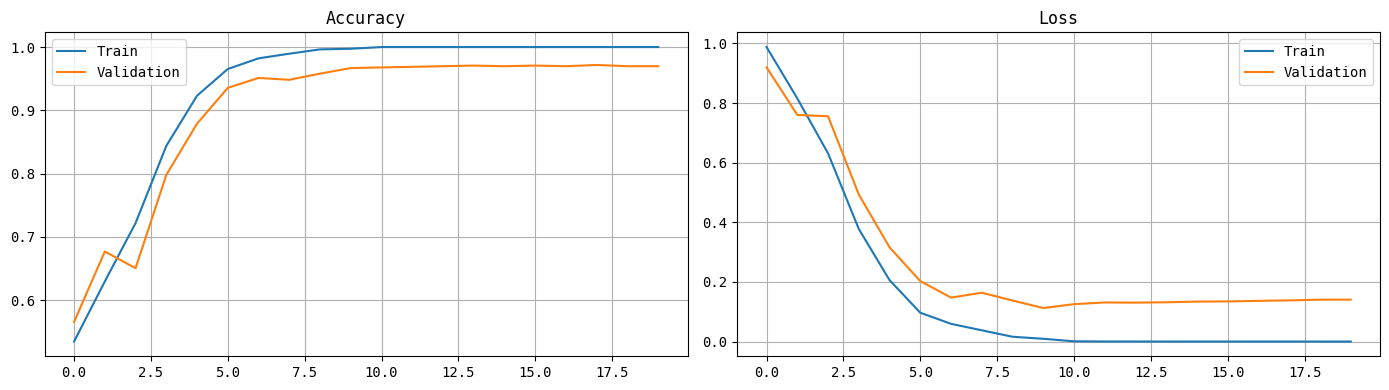

In [ ]:


# Training
history = model.fit(
    train_images, train_labels_cat,
    epochs=20,
    batch_size=32,
    validation_split=0.2,  # 20% del train usato per monitorare durante il training
    verbose=1
)

# Valutazione sul test set
test_loss, test_acc = model.evaluate(test_images, test_labels_cat, verbose=0)
print(f"Test accuracy: {test_acc:.4f}  |  Test loss: {test_loss:.4f}")

# Grafici loss e accuracy
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
ax1.plot(history.history['accuracy'],     label='Train')
ax1.plot(history.history['val_accuracy'], label='Validation')
ax1.set_title('Accuracy'); ax1.legend(); ax1.grid(True)
ax2.plot(history.history['loss'],     label='Train')
ax2.plot(history.history['val_loss'], label='Validation')
ax2.set_title('Loss'); ax2.legend(); ax2.grid(True)
plt.tight_layout()
plt.rcParams['font.family'] = 'monospace'
plt.show()

In [ ]:
# epoca migliore (con loss minima)
best_epoch = np.argmin(history.history['val_loss']) + 1
best_val_loss = min(history.history['val_loss'])
best_val_acc  = history.history['val_accuracy'][best_epoch - 1]

print(f"Epoca migliore:        {best_epoch}")
print(f"Val loss migliore:     {best_val_loss:.4f}")
print(f"Val accuracy migliore: {best_val_acc:.4f}")

Epoca migliore:        10
Val loss migliore:     0.1124
Val accuracy migliore: 0.9668


40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


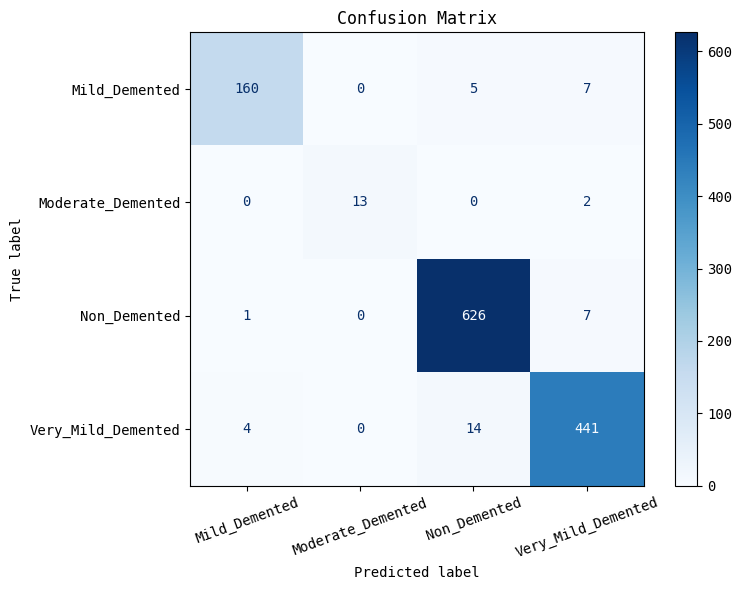

                    precision    recall  f1-score   support

     Mild_Demented       0.97      0.93      0.95       172
 Moderate_Demented       1.00      0.87      0.93        15
      Non_Demented       0.97      0.99      0.98       634
Very_Mild_Demented       0.96      0.96      0.96       459

          accuracy                           0.97      1280
         macro avg       0.98      0.94      0.95      1280
      weighted avg       0.97      0.97      0.97      1280



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# predizioni sul test set — argmax converte da one-hot al numero della classe
test_pred = np.argmax(model.predict(test_images), axis=1)

# confusion matrix
cm = confusion_matrix(test_labels, test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, colorbar=True, cmap='Blues')
plt.xticks(rotation=20)
plt.title('Confusion Matrix')
plt.tight_layout()
plt.rcParams['font.family'] = 'monospace'
plt.show()

# classification report — stampa precision, recall, f1 per ogni classe
# precision: quante predizioni positive erano davvero positive
# recall:    quante positive reali ha trovato il modello
# f1:        media armonica tra precision e recall — bilancia i due
print(classification_report(test_labels, test_pred, target_names=label_names))

In [ ]:
'''
# verifica sovrapposizione tra train e test
# se ci sono immagini identiche il modello ha "barato"
train_flat = train_images.reshape(len(train_images), -1)
test_flat  = test_images.reshape(len(test_images), -1)

duplicati = 0
for i, test_img in enumerate(test_flat):
    if np.any(np.all(train_flat == test_img, axis=1)):
        duplicati += 1
    print(f"Controllato {i+1}/{len(test_flat)}", end='\r')

print(f"\nImmagini test identiche a immagini train: {duplicati} su {len(test_images)}")
'''

#eseguito una volta dato come risultato 0
#esiste perchè al primo tentativo ha dato un valore molto alto di successo.

KeyboardInterrupt: 

Salvataggio di un file json con i risultati ottenuti con questo modello

In [ ]:
import json
from datetime import datetime

risultati = {
    'timestamp': datetime.now().strftime("%Y-%m-%d %H:%M"),
    'modello': 'CNN_from_scratch_NoWeightsOnClass',
    'epoche_eseguite': len(history.history['loss']),
    'test_accuracy': float(test_acc),
    'test_loss': float(test_loss),
    'train_accuracy_finale': float(history.history['accuracy'][-1]),
    'val_accuracy_finale': float(history.history['val_accuracy'][-1]),
    'class_weights_usati': False,
    'confusion_matrix': cm.tolist(),
    'classification_report': classification_report(
        test_labels, test_pred,
        target_names=label_names,
        output_dict=True
    )
}

path = f'/content/drive/MyDrive/Project_For_ABIAML/risultati_CNN_scratch_seed{seed}.json'
with open(path, 'w') as f:
    json.dump(risultati, f, indent=2)

print(f"Salvato in: {path}")
print(f"Test accuracy: {test_acc:.4f}")
print(f"Macro F1: {risultati['classification_report']['macro avg']['f1-score']:.4f}")

Salvato in: /content/drive/MyDrive/Project_For_ABIAML/risultati_CNN_scratch_seed42.json
Test accuracy: 0.9688
Macro F1: 0.9550


Salvataggio del modello

In [ ]:
from datetime import datetime

timestamp = datetime.now().strftime("%Y%m%d_%H%M")
path = f'/content/drive/MyDrive/Project_For_ABIAML/risultati_CNN_scratch_{timestamp}.keras'
model.save(path)